In [7]:
%load_ext autoreload
%autoreload 2
import numpy as np
from pyomo.environ import *
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
from reheat.core import *
from reheat.results import *
from pathlib import Path
current_file_path = Path.cwd()
Path('plots').mkdir(exist_ok=True)
Path('results').mkdir(exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
x = 11
plt.rcParams.update({
    "font.family": "serif",
    "font.size": x,
    "axes.titlesize": x+1,
    "axes.labelsize": x,
    "xtick.labelsize": x-1,
    "ytick.labelsize": x-1,
    "legend.fontsize": x-1,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "figure.dpi": 100,
})

In [6]:
p = initialize_params()
r1 = run_optimization(p)

Optimization Finished Successfully


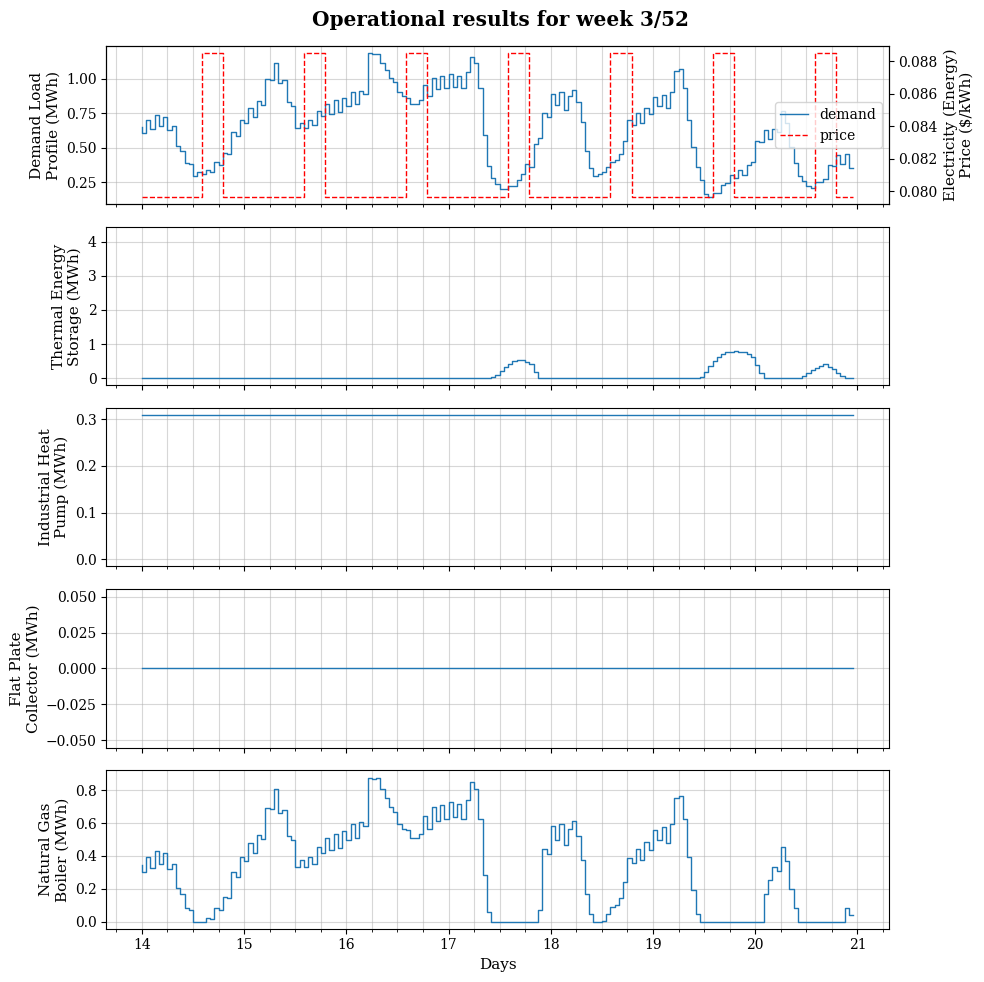

In [8]:
r1.plot_results(week=3)
plt.savefig('plots/plot_results_base_case.png', dpi=300, bbox_inches = "tight")

In [9]:
r1.print_results()

-----------------
Financial Metrics
-----------------
total_cost = 2,034,805.60 $
capex = 463,610.29 $
opex = 1,571,195.40 $
capex fraction of total cost = 0.23
opex fraction of total cost = 0.77
-----------------
Financial Metrics by Technology
-----------------
capex_IHP = 246,510.34 $
capex_TES = 42,133.36 $
capex_NGB = 174,966.58 $
capex_FPC = 0.00 $
annual opex = 90,230.40 $/year
opex_IHP = 45,550.44 $/year
opex_IHP_peak = 14.81 $/year
opex_NGB = 44,665.15 $/year
-----------------
Heat Generation
-----------------
Q_IHP = 1,615.79 MWh/year
Q_NGB = 1,138.72 MWh/year
Q_FPC = 0.00 MWh/year
-----------------
Equipment Sizing
-----------------
Q_IHP_max = 0.31 MW
Q_NGB_max = 1.46 MW
Q_FPC_max = 0.00 MW
Q_TES_max = 4.21 MWh + 0.75 MW
-----------------
Electricity Metrics
-----------------
W_IHP = 538.60 MWh/year
W_IHP_monthly_max = 0.10 MW (Annual Peak)


# High fuel prices

In [10]:
p = initialize_params()
p.price_NG = p.price_NG*10
r2 = run_optimization(p)

Optimization Finished Successfully


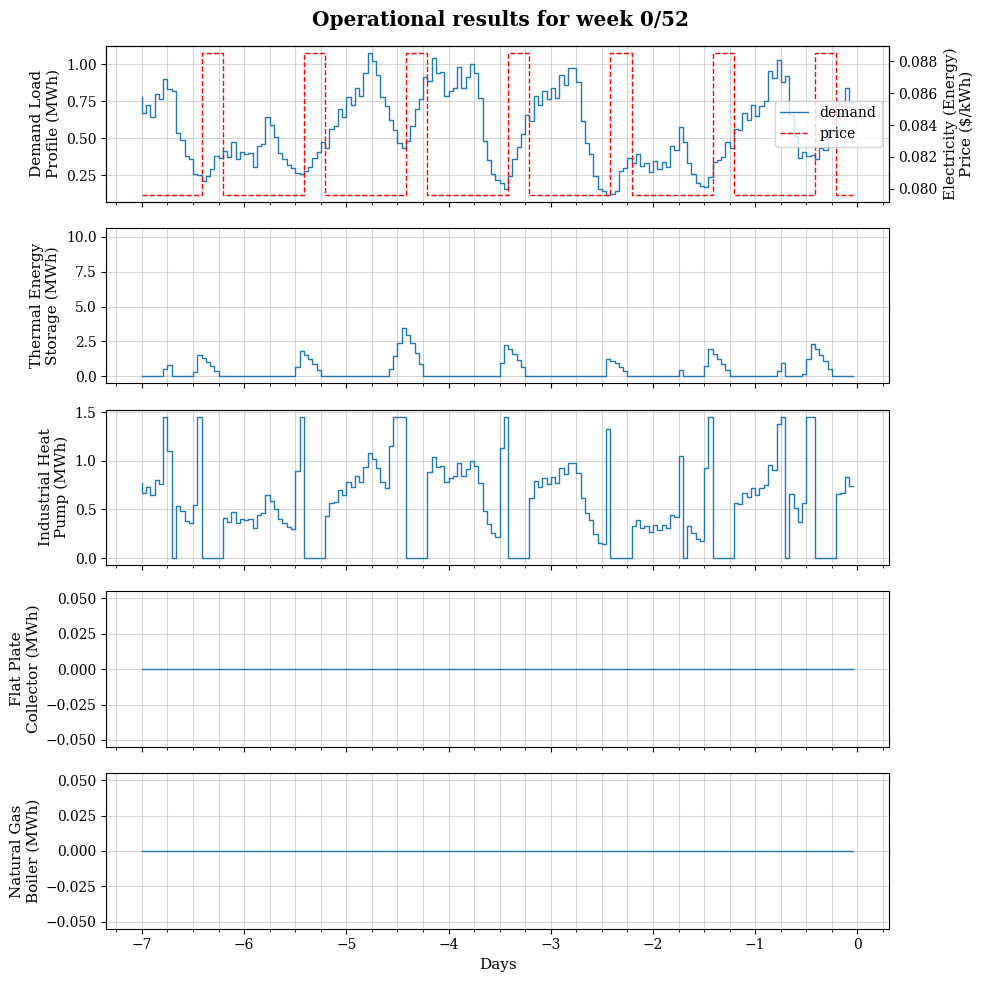

In [11]:
r2.plot_results(week=0)

In [12]:
r2.print_results()

-----------------
Financial Metrics
-----------------
total_cost = 2,613,299.80 $
capex = 1,270,449.60 $
opex = 1,342,850.20 $
capex fraction of total cost = 0.49
opex fraction of total cost = 0.51
-----------------
Financial Metrics by Technology
-----------------
capex_IHP = 1,163,260.80 $
capex_TES = 101,491.98 $
capex_NGB = 5,696.84 $
capex_FPC = 0.00 $
annual opex = 77,117.03 $/year
opex_IHP = 75,498.79 $/year
opex_IHP_peak = 25.22 $/year
opex_NGB = 1,593.01 $/year
-----------------
Heat Generation
-----------------
Q_IHP = 2,749.86 MWh/year
Q_NGB = 4.65 MWh/year
Q_FPC = 0.00 MWh/year
-----------------
Equipment Sizing
-----------------
Q_IHP_max = 1.45 MW
Q_NGB_max = 0.05 MW
Q_FPC_max = 0.00 MW
Q_TES_max = 10.15 MWh + 1.57 MW
-----------------
Electricity Metrics
-----------------
W_IHP = 916.62 MWh/year
W_IHP_monthly_max = 0.26 MW (Annual Peak)


# High fuel and electricity prices (equivalently, low FPC capital cost)

In [13]:
p = initialize_params()
p.price_NG = p.price_NG*10
p.price_energy = p.price_energy*5
r3 = run_optimization(p)

Optimization Finished Successfully


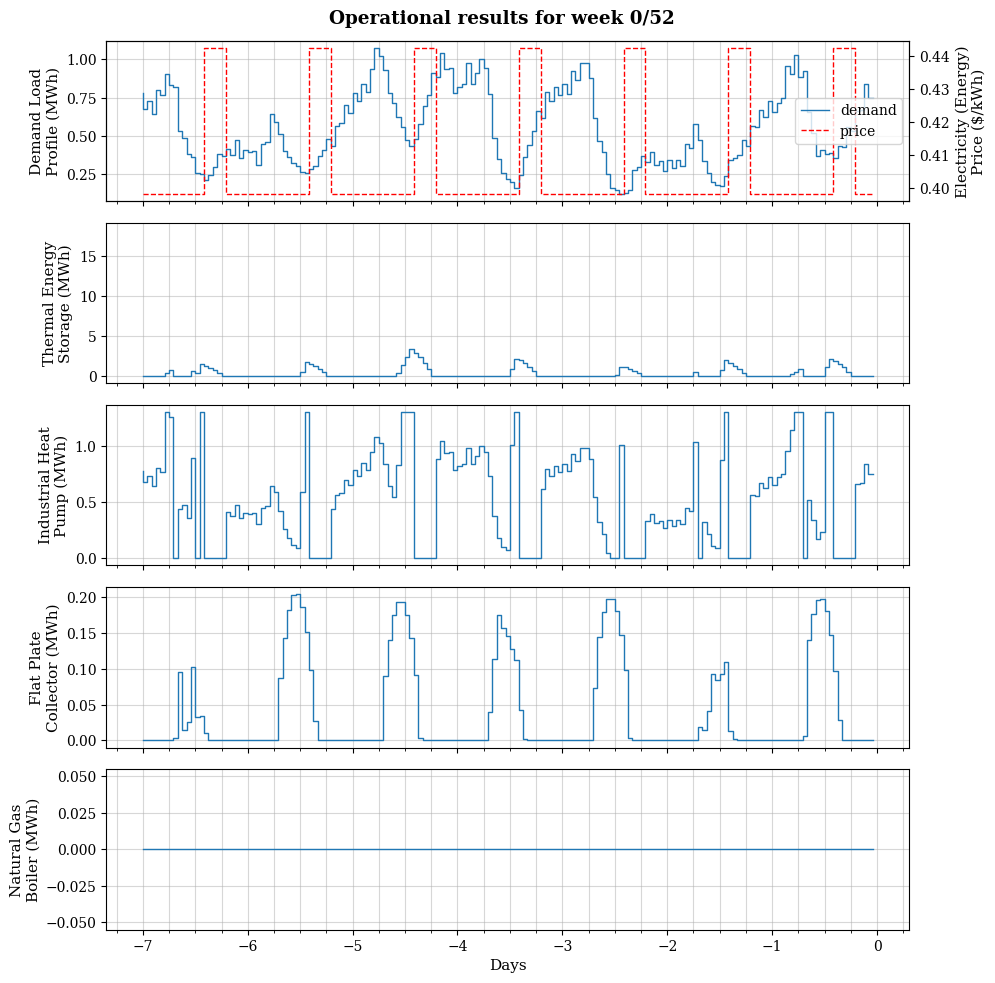

In [31]:
r3.plot_results(week=0)

In [14]:
r3.print_results()

-----------------
Financial Metrics
-----------------
total_cost = 7,100,778.50 $
capex = 1,470,778.90 $
opex = 5,629,999.60 $
capex fraction of total cost = 0.21
opex fraction of total cost = 0.79
-----------------
Financial Metrics by Technology
-----------------
capex_IHP = 1,037,824.60 $
capex_TES = 183,049.02 $
capex_NGB = 11,254.57 $
capex_FPC = 238,650.67 $
annual opex = 323,318.89 $/year
opex_IHP = 319,964.64 $/year
opex_IHP_peak = 21.51 $/year
opex_NGB = 3,332.73 $/year
-----------------
Heat Generation
-----------------
Q_IHP = 2,343.67 MWh/year
Q_NGB = 9.72 MWh/year
Q_FPC = 401.11 MWh/year
-----------------
Equipment Sizing
-----------------
Q_IHP_max = 1.30 MW
Q_NGB_max = 0.09 MW
Q_FPC_max = 0.24 MW
Q_TES_max = 18.30 MWh + 1.66 MW
-----------------
Electricity Metrics
-----------------
W_IHP = 781.22 MWh/year
W_IHP_monthly_max = 0.25 MW (Annual Peak)


# Sensitivity Analyses

# TES Capex vs. Size

In [33]:
capex_var_TES_list = np.linspace(10, 125, 31)  # $/Mwh
results = []

p = initialize_params()

for capex_var_TES in capex_var_TES_list:

    p.capex_var_TES = capex_var_TES*1000
    res = run_optimization(p, print_flag=False)

    print(f"Finished capex_var_TES = {capex_var_TES:n}")
    results.append(res)

Finished capex_var_TES = 10
Finished capex_var_TES = 13.8333
Finished capex_var_TES = 17.6667
Finished capex_var_TES = 21.5
Finished capex_var_TES = 25.3333
Finished capex_var_TES = 29.1667
Finished capex_var_TES = 33
Finished capex_var_TES = 36.8333
Finished capex_var_TES = 40.6667
Finished capex_var_TES = 44.5
Finished capex_var_TES = 48.3333
Finished capex_var_TES = 52.1667
Finished capex_var_TES = 56
Finished capex_var_TES = 59.8333
Finished capex_var_TES = 63.6667
Finished capex_var_TES = 67.5
Finished capex_var_TES = 71.3333
Finished capex_var_TES = 75.1667
Finished capex_var_TES = 79
Finished capex_var_TES = 82.8333
Finished capex_var_TES = 86.6667
Finished capex_var_TES = 90.5
Finished capex_var_TES = 94.3333
Finished capex_var_TES = 98.1667
Finished capex_var_TES = 102
Finished capex_var_TES = 105.833
Finished capex_var_TES = 109.667
Finished capex_var_TES = 113.5
Finished capex_var_TES = 117.333
Finished capex_var_TES = 121.167
Finished capex_var_TES = 125


In [34]:
filename = "results/results_sensitivity_analysis_tes_price_per_energy.dat"
with open(filename, "wb") as f:
    pickle.dump(results, f)

In [20]:
filename = "results/results_sensitivity_analysis_tes_price_per_energy.dat"
with open(filename, "rb") as f:
    results = pickle.load(f)
capex_var_TES_list = np.linspace(10, 125, 31)  # $/Mwh

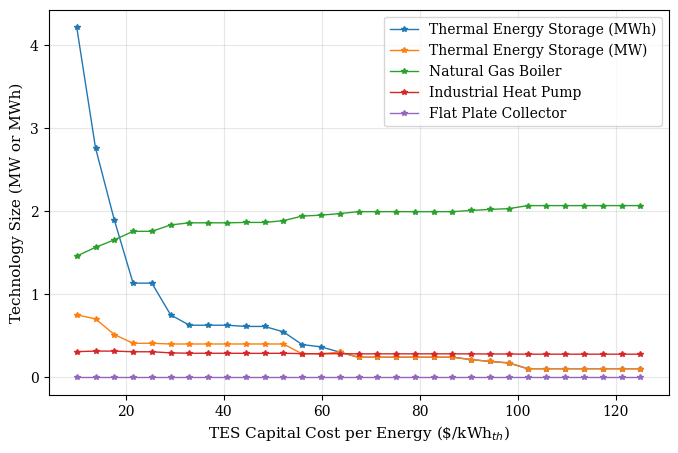

In [21]:
Q_TES_max = [r.Q_TES_max for r in results]
Q_TES_diff_max = [r.Q_TES_diff_max for r in results]
Q_IHP_max = [r.Q_IHP_max for r in results]
Q_NGB_max = [r.Q_NGB_max for r in results]
Q_FPC_max = [r.Q_FPC_max for r in results]
plt.figure(figsize=(8, 5))
plt.plot(capex_var_TES_list, Q_TES_max, "-*", label='Thermal Energy Storage (MWh)')
plt.plot(capex_var_TES_list, Q_TES_diff_max, "-*", label='Thermal Energy Storage (MW)')
plt.plot(capex_var_TES_list, Q_NGB_max, "-*", label='Natural Gas Boiler')
plt.plot(capex_var_TES_list, Q_IHP_max, "-*", label='Industrial Heat Pump')
plt.plot(capex_var_TES_list, Q_FPC_max, "-*", label='Flat Plate Collector')
plt.legend()
plt.xlabel(r"TES Capital Cost per Energy (\$/kWh$_{th}$)")
plt.ylabel("Technology Size (MW or MWh)")
plt.grid(alpha=0.3)
plt.savefig('plots/sensitivity_analysis_tes_price_per_energy.png', dpi=300, bbox_inches = "tight")

# TES Heat Transfer Rate Cost

In [37]:
capex_var_TES_diff_list = np.linspace(0, 500, 31)  # $/kW
# capex_var_TES_diff_list = [0, 100, 500]  # $/MW
results_capex_var_TES_diff = []

for capex_var_TES_diff in capex_var_TES_diff_list:

    p = initialize_params()
    # change params
    p.capex_var_TES_diff = capex_var_TES_diff*1e3
    res = run_optimization(p, print_flag=False)

    results_capex_var_TES_diff.append(res)

In [38]:
filename = "results/results_sensitivity_analysis_tes_price_per_rate.dat"
with open(filename, "wb") as f:
    pickle.dump(results_capex_var_TES_diff, f)

In [39]:
filename = "results/results_sensitivity_analysis_tes_price_per_rate.dat"
with open(filename, "rb") as f:
    results_capex_var_TES_diff = pickle.load(f)

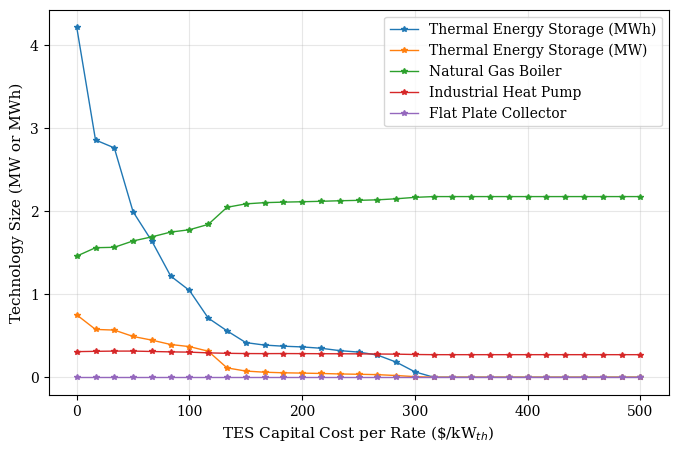

In [40]:
results = results_capex_var_TES_diff
Q_TES_max = [r.Q_TES_max for r in results]
Q_TES_diff_max = [r.Q_TES_diff_max for r in results]
Q_IHP_max = [r.Q_IHP_max for r in results]
Q_NGB_max = [r.Q_NGB_max for r in results]
Q_FPC_max = [r.Q_FPC_max for r in results]
plt.figure(figsize=(8, 5))
plt.plot(capex_var_TES_diff_list, Q_TES_max, "-*", label='Thermal Energy Storage (MWh)')
plt.plot(capex_var_TES_diff_list, Q_TES_diff_max, "-*", label='Thermal Energy Storage (MW)')
plt.plot(capex_var_TES_diff_list, Q_NGB_max, "-*", label='Natural Gas Boiler')
plt.plot(capex_var_TES_diff_list, Q_IHP_max, "-*", label='Industrial Heat Pump')
plt.plot(capex_var_TES_diff_list, Q_FPC_max, "-*", label='Flat Plate Collector')
plt.legend()
plt.xlabel(r"TES Capital Cost per Rate (\$/kW$_{th}$)")
plt.ylabel("Technology Size (MW or MWh)")
plt.grid(alpha=0.3)
plt.savefig('plots/sensitivity_analysis_tes_price_per_rate.png', dpi=300, bbox_inches = "tight")

# Emission Cost

In [41]:
carbon_offset_price_list = np.linspace(1, 500, 31)  # $/ton_co2
results_carbon_offset_price = []

for carbon_offset_price in carbon_offset_price_list:

    p = initialize_params()
    # change params
    p.carbon_offset_price = carbon_offset_price
    res = run_optimization(p, print_flag=False)

    print(f"Finished carbon_offset_price = {carbon_offset_price:n}")

    results_carbon_offset_price.append(res)

Finished carbon_offset_price = 1
Finished carbon_offset_price = 17.6333
Finished carbon_offset_price = 34.2667
Finished carbon_offset_price = 50.9
Finished carbon_offset_price = 67.5333
Finished carbon_offset_price = 84.1667
Finished carbon_offset_price = 100.8
Finished carbon_offset_price = 117.433
Finished carbon_offset_price = 134.067
Finished carbon_offset_price = 150.7
Finished carbon_offset_price = 167.333
Finished carbon_offset_price = 183.967
Finished carbon_offset_price = 200.6
Finished carbon_offset_price = 217.233
Finished carbon_offset_price = 233.867
Finished carbon_offset_price = 250.5
Finished carbon_offset_price = 267.133
Finished carbon_offset_price = 283.767
Finished carbon_offset_price = 300.4
Finished carbon_offset_price = 317.033
Finished carbon_offset_price = 333.667
Finished carbon_offset_price = 350.3
Finished carbon_offset_price = 366.933
Finished carbon_offset_price = 383.567
Finished carbon_offset_price = 400.2
Finished carbon_offset_price = 416.833
Finished 

In [42]:
filename = "results/results_sensitivity_analysis_carbon_offset_price.dat"
with open(filename, "wb") as f:
    pickle.dump(results_carbon_offset_price, f)

In [43]:
filename = "results/results_sensitivity_analysis_carbon_offset_price.dat"
with open(filename, "rb") as f:
    results_carbon_offset_price = pickle.load(f)

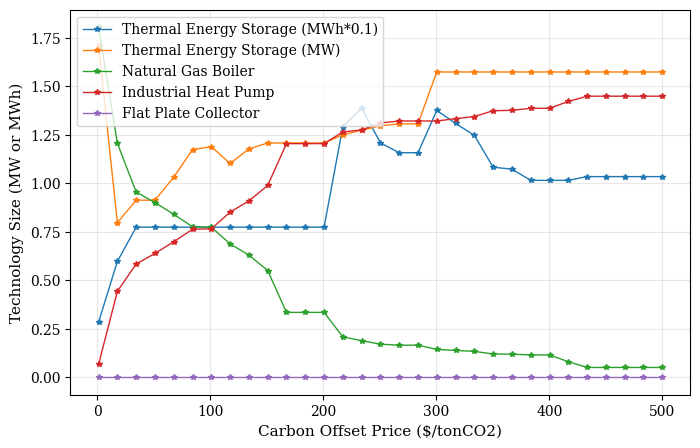

In [44]:
x = carbon_offset_price_list
results = results_carbon_offset_price
Q_TES_max = [r.Q_TES_max for r in results]
Q_TES_diff_max = [r.Q_TES_diff_max for r in results]
Q_IHP_max = [r.Q_IHP_max for r in results]
Q_NGB_max = [r.Q_NGB_max for r in results]
Q_FPC_max = [r.Q_FPC_max for r in results]
plt.figure(figsize=(8, 5))
plt.plot(x, [y/10 for y in Q_TES_max], "-*", label='Thermal Energy Storage (MWh*0.1)')
plt.plot(x, Q_TES_diff_max, "-*", label='Thermal Energy Storage (MW)')
plt.plot(x, Q_NGB_max, "-*", label='Natural Gas Boiler')
plt.plot(x, Q_IHP_max, "-*", label='Industrial Heat Pump')
plt.plot(x, Q_FPC_max, "-*", label='Flat Plate Collector')
plt.legend()
plt.xlabel("Carbon Offset Price ($/tonCO2)")
plt.ylabel("Technology Size (MW or MWh)")
plt.grid(alpha=0.3)
plt.savefig('plots/sensitivity_analysis_carbon_offset_price.png', dpi=300, bbox_inches = "tight")

# Fuel Prices

In [45]:
natural_gas_price_list = np.linspace(1, 200, 31)  # $/MWh
results_natural_gas_price = []

for natural_gas_price in natural_gas_price_list:

    p = initialize_params()
    # change params
    p.price_NG = natural_gas_price
    res = run_optimization(p, print_flag=False)

    print(f"Finished natural_gas_price = {natural_gas_price:n}")

    results_natural_gas_price.append(res)

Finished natural_gas_price = 1
Finished natural_gas_price = 7.63333
Finished natural_gas_price = 14.2667
Finished natural_gas_price = 20.9
Finished natural_gas_price = 27.5333
Finished natural_gas_price = 34.1667
Finished natural_gas_price = 40.8
Finished natural_gas_price = 47.4333
Finished natural_gas_price = 54.0667
Finished natural_gas_price = 60.7
Finished natural_gas_price = 67.3333
Finished natural_gas_price = 73.9667
Finished natural_gas_price = 80.6
Finished natural_gas_price = 87.2333
Finished natural_gas_price = 93.8667
Finished natural_gas_price = 100.5
Finished natural_gas_price = 107.133
Finished natural_gas_price = 113.767
Finished natural_gas_price = 120.4
Finished natural_gas_price = 127.033
Finished natural_gas_price = 133.667
Finished natural_gas_price = 140.3
Finished natural_gas_price = 146.933
Finished natural_gas_price = 153.567
Finished natural_gas_price = 160.2
Finished natural_gas_price = 166.833
Finished natural_gas_price = 173.467
Finished natural_gas_price 

In [46]:
filename = "results/results_sensitivity_analysis_natural_gas_price.dat"
with open(filename, "wb") as f:
    pickle.dump(results_natural_gas_price, f)

In [47]:
filename = "results/results_sensitivity_analysis_natural_gas_price.dat"
with open(filename, "rb") as f:
    results_natural_gas_price = pickle.load(f)

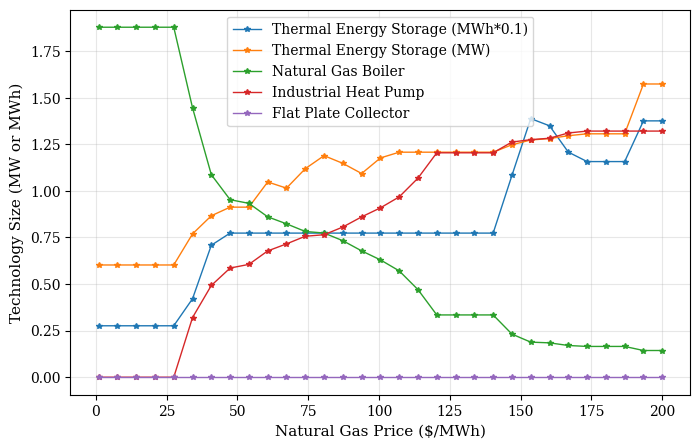

In [48]:
x = natural_gas_price_list
results = results_natural_gas_price
Q_TES_max = [r.Q_TES_max for r in results]
Q_TES_diff_max = [r.Q_TES_diff_max for r in results]
Q_IHP_max = [r.Q_IHP_max for r in results]
Q_NGB_max = [r.Q_NGB_max for r in results]
Q_FPC_max = [r.Q_FPC_max for r in results]
plt.figure(figsize=(8, 5))
plt.plot(x, [y/10 for y in Q_TES_max], "-*", label='Thermal Energy Storage (MWh*0.1)')
plt.plot(x, Q_TES_diff_max, "-*", label='Thermal Energy Storage (MW)')
plt.plot(x, Q_NGB_max, "-*", label='Natural Gas Boiler')
plt.plot(x, Q_IHP_max, "-*", label='Industrial Heat Pump')
plt.plot(x, Q_FPC_max, "-*", label='Flat Plate Collector')
plt.legend()
plt.xlabel("Natural Gas Price ($/MWh)")
plt.ylabel("Technology Size (MW or MWh)")
plt.grid(alpha=0.3)
plt.savefig('plots/sensitivity_analysis_natural_gas_price.png', dpi=300, bbox_inches = "tight")

# FPC Capital Cost

In [49]:
FPC_capex_list = np.linspace(100, 2000, 31)  # $/kWh
results_FPC_capex = []

for FPC_capex in FPC_capex_list:

    p = initialize_params()

    # change params
    p.capex_var_FPC = FPC_capex*1000
    res = run_optimization(p, print_flag=False)

    print(f"Finished FPC_capex = {FPC_capex:n}")

    results_FPC_capex.append(res)

Finished FPC_capex = 100
Finished FPC_capex = 163.333
Finished FPC_capex = 226.667
Finished FPC_capex = 290
Finished FPC_capex = 353.333
Finished FPC_capex = 416.667
Finished FPC_capex = 480
Finished FPC_capex = 543.333
Finished FPC_capex = 606.667
Finished FPC_capex = 670
Finished FPC_capex = 733.333
Finished FPC_capex = 796.667
Finished FPC_capex = 860
Finished FPC_capex = 923.333
Finished FPC_capex = 986.667
Finished FPC_capex = 1050
Finished FPC_capex = 1113.33
Finished FPC_capex = 1176.67
Finished FPC_capex = 1240
Finished FPC_capex = 1303.33
Finished FPC_capex = 1366.67
Finished FPC_capex = 1430
Finished FPC_capex = 1493.33
Finished FPC_capex = 1556.67
Finished FPC_capex = 1620
Finished FPC_capex = 1683.33
Finished FPC_capex = 1746.67
Finished FPC_capex = 1810
Finished FPC_capex = 1873.33
Finished FPC_capex = 1936.67
Finished FPC_capex = 2000


In [50]:
filename = "results/results_sensitivity_analysis_fpc_capex.dat"
with open(filename, "wb") as f:
    pickle.dump(results_FPC_capex, f)

In [51]:
filename = "results/results_sensitivity_analysis_fpc_capex.dat"
with open(filename, "rb") as f:
    results_FPC_capex = pickle.load(f)
FPC_capex_list = np.linspace(100, 2000, 31)  # $/kWh

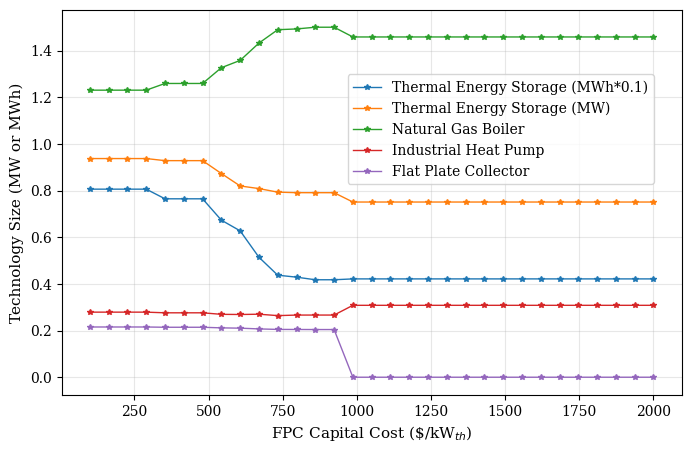

In [52]:
x = FPC_capex_list
results = results_FPC_capex
Q_TES_max = [r.Q_TES_max for r in results]
Q_TES_diff_max = [r.Q_TES_diff_max for r in results]
Q_IHP_max = [r.Q_IHP_max for r in results]
Q_NGB_max = [r.Q_NGB_max for r in results]
Q_FPC_max = [r.Q_FPC_max for r in results]
plt.figure(figsize=(8, 5))
plt.plot(x, [y/10 for y in Q_TES_max], "-*", label='Thermal Energy Storage (MWh*0.1)')
plt.plot(x, Q_TES_diff_max, "-*", label='Thermal Energy Storage (MW)')
plt.plot(x, Q_NGB_max, "-*", label='Natural Gas Boiler')
plt.plot(x, Q_IHP_max, "-*", label='Industrial Heat Pump')
plt.plot(x, Q_FPC_max, "-*", label='Flat Plate Collector')
plt.xlabel(r"FPC Capital Cost (\$/kW$_{th}$)")
plt.ylabel("Technology Size (MW or MWh)")
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(0.45, 0.85))
plt.savefig('plots/sensitivity_analysis_fpc_capex.png', dpi=300, bbox_inches = "tight")